<a href="https://colab.research.google.com/github/Anuhya1024/XR-Brain/blob/main/05_support_vector_machines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*   Anuhya Mandalapu
*   Module 3 Assignment on SVM



**Support Vector Machines**

_This notebook contains all the sample code and solutions to the exercises in chapter 5._

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/05_support_vector_machines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/05_support_vector_machines.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

This project requires Python 3.7 or above:

In [20]:
import sys

assert sys.version_info >= (3, 7)

It also requires Scikit-Learn ≥ 1.0.1:

In [21]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

As we did in previous chapters, let's define the default font sizes to make the figures prettier:

In [22]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

And let's create the `images/svm` folder (if it doesn't already exist), and define the `save_fig()` function which is used through this notebook to save the figures in high-res for the book:

In [23]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "svm"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

We'll also need a few extra imports for this exercise (models, scaler, pipeline helper, and numpy for the visualization at the end):

In [24]:
import numpy as np
from sklearn.svm import LinearSVC, SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 10.

_Exercise: Train an SVM classifier on the Wine dataset, which you can load using `sklearn.datasets.load_wine()`. This dataset contains the chemical analysis of 178 wine samples produced by 3 different cultivators: the goal is to train a classification model capable of predicting the cultivator based on the wine's chemical analysis. Since SVM classifiers are binary classifiers, you will need to use one-versus-all to classify all 3 classes. What accuracy can you reach?_

First, let's fetch the dataset, look at its description, then split it into a training set and a test set:

In [25]:
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)

In [26]:
print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

**What do classes 0, 1, and 2 represent, and what are we trying to do with this SVM?**

The Wine dataset contains chemical measurements (alcohol content, malic acid, ash, magnesium, color intensity, etc.) for 178 wine samples. Each sample was actually produced by one of **3 different grape growers/cultivators** in the same region of Italy, and the dataset labels each sample with which cultivator grew it:

- **Class 0** — wines from cultivar 1
- **Class 1** — wines from cultivar 2
- **Class 2** — wines from cultivar 3

These are just arbitrary integer labels assigned to the three cultivators — there's no ranking or ordering implied (class 2 isn't "more" than class 1, it's simply a different grower).

**Our goal** is to train a Support Vector Machine (SVM) classifier that looks only at a wine's chemical analysis (the 13 numeric features) and predicts *which of the three cultivators* grew it. This is a **multiclass classification** problem. Since SVMs are naturally *binary* classifiers (they only know how to separate two classes with a decision boundary), scikit-learn handles the 3-class case automatically using the **One-vs-Rest (OvR)** strategy: it trains 3 separate binary SVMs behind the scenes (class 0 vs. not-class-0, class 1 vs. not-class-1, class 2 vs. not-class-2) and picks whichever one is most confident for a given wine.

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    wine.data, wine.target, random_state=42)

In [28]:
X_train.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
100,12.08,2.08,1.70,17.5,97.0,2.23,2.17,0.26,1.40,3.30,1.27,2.96,710.0
122,12.42,4.43,2.73,26.5,102.0,2.20,2.13,0.43,1.71,2.08,0.92,3.12,365.0
154,12.58,1.29,2.10,20.0,103.0,1.48,0.58,0.53,1.40,7.60,0.58,1.55,640.0
51,13.83,1.65,2.60,17.2,94.0,2.45,2.99,0.22,2.29,5.60,1.24,3.37,1265.0


In [29]:
y_train.head()

,target
2,0
100,1
122,1
154,2
51,0


Let's start simple, with a linear SVM classifier. It will automatically use the One-vs-All (also called One-vs-the-Rest, OvR) strategy, so there's nothing special we need to do to handle multiple classes. Easy, right?

In [30]:
lin_clf = LinearSVC(dual=True, random_state=42)
lin_clf.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(dual=True, random_state=42)

Oh no! It failed to converge. Can you guess why? Do you think we must just increase the number of training iterations? Let's see:

**Why did `LinearSVC` fail to converge?**

`LinearSVC` is trained using an iterative optimization algorithm (a form of gradient-based solver) that repeatedly adjusts the model's weights to minimize the loss. This process works much better — and converges much faster — when all the input features are on roughly the **same numeric scale**.

The Wine dataset's raw features have wildly different scales: for example, `proline` ranges into the hundreds or low thousands, while `hue` and `nonflavanoid_phenols` are small decimals well under 1. When features have such different magnitudes, the optimizer's loss surface becomes very elongated/skewed in some directions and flat in others, so gradient-based steps zig-zag and make very slow, inefficient progress toward the minimum. Just cranking up `max_iter` (as we try next) doesn't fix the underlying geometry of the problem — it just lets the slow, zig-zagging process run longer, which is why even a million iterations isn't guaranteed to fully converge. The real fix (shown a couple of cells below) is to **scale the features first**.

In [31]:
lin_clf = LinearSVC(max_iter=1_000_000, dual=True, random_state=42)
lin_clf.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(dual=True, max_iter=1000000, random_state=42)

Even with one million iterations, it still did not converge. There must be another problem.

Let's still evaluate this model with `cross_val_score`, it will serve as a baseline:

In [32]:
from sklearn.model_selection import cross_val_score

cross_val_score(lin_clf, X_train, y_train).mean()

/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


np.float64(0.90997150997151)

Well 91% accuracy on this dataset is not great. So did you guess what the problem is?

That's right, we forgot to scale the features! Always remember to scale the features when using SVMs:

**What is "scaling the features"?**

Feature scaling means transforming each numeric input column so that they all live on a comparable range, instead of leaving them in their original, wildly different units and magnitudes. A very common way to do this — and the one used here via `StandardScaler` — is **standardization**: for every feature, subtract its mean and divide by its standard deviation, so the transformed feature ends up with a mean of 0 and a standard deviation of 1.

$$x_{scaled} = \frac{x - \mu}{\sigma}$$

This matters enormously for SVMs (and many other algorithms, like k-NN, PCA, and gradient-descent-based models) because they are sensitive to the *distances* and *gradients* involved in the input space. Without scaling, a feature like `proline` (values in the hundreds) would dominate the distance calculations and the loss landscape purely because of its large numeric range — not because it's actually more important — while small-scale features like `hue` would barely register. Scaling puts every feature on equal footing so the model can learn genuine patterns, and it also makes the optimizer's job numerically well-behaved, which is exactly why it fixes the convergence problem above.

In [33]:
lin_clf = make_pipeline(StandardScaler(),
                        LinearSVC(dual=True, random_state=42))
lin_clf.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvc', LinearSVC(dual=True, random_state=42))])

Now it converges without any problem. Let's measure its performance:

In [34]:
from sklearn.model_selection import cross_val_score

cross_val_score(lin_clf, X_train, y_train).mean()

np.float64(0.9774928774928775)

Nice! We get 97.7% accuracy, that's much better.

Let's see if a kernelized SVM will do better. We will use a default `SVC` for now:

**What is a "kernelized SVM"?**

A plain linear SVM (like `LinearSVC`) can only draw a **straight-line (or flat hyperplane) decision boundary** between classes. That works well when classes are linearly separable, but many real datasets need a *curved* or more complex boundary to separate classes well.

A **kernelized SVM** (scikit-learn's `SVC` class) solves this using the **kernel trick**: instead of explicitly transforming the data into a higher-dimensional space and computing a linear boundary there (which would be computationally expensive), it uses a *kernel function* to efficiently compute what the similarity between two data points *would* look like in that higher-dimensional space, without ever actually computing the transformation. Common kernels include:

- **Linear** — equivalent to a straight-line boundary (similar to `LinearSVC`)
- **RBF (Radial Basis Function / Gaussian)** — the default for `SVC`, capable of drawing smooth, curved, highly flexible boundaries
- **Polynomial** — boundaries shaped like polynomial curves

Because `SVC` with an RBF kernel can bend its decision boundary to fit more complex patterns in the data, it's often more powerful than a linear SVM — but it also has more hyperparameters (like `C` and `gamma`) that need to be tuned properly, or it can underfit or overfit.

In [35]:
svm_clf = make_pipeline(StandardScaler(), SVC(random_state=42))
cross_val_score(svm_clf, X_train, y_train).mean()

np.float64(0.9698005698005698)

That's not better, but perhaps we need to do a bit of hyperparameter tuning:

In [36]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform

param_distrib = {
    "svc__gamma": loguniform(0.001, 0.1),
    "svc__C": uniform(1, 10)
}
rnd_search_cv = RandomizedSearchCV(svm_clf, param_distrib, n_iter=100, cv=5,
                                   random_state=42)
rnd_search_cv.fit(X_train, y_train)
rnd_search_cv.best_estimator_

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc',
                 SVC(C=np.float64(9.925589984899778),
                     gamma=np.float64(0.011986281799901188),
                     random_state=42))])

In [37]:
rnd_search_cv.best_score_

np.float64(0.9925925925925926)

Ah, this looks excellent! Let's select this model. Now we can test it on the test set:

In [38]:
rnd_search_cv.score(X_test, y_test)

0.9777777777777777

**What do these results mean?**

`rnd_search_cv.best_score_` reports the best **cross-validated** accuracy found during the random search over the *training* set — essentially, "how well did the best hyperparameter combination do, on average, across the 5 cross-validation folds carved out of the training data?"

`rnd_search_cv.score(X_test, y_test)` then evaluates that same best model on the **held-out test set** — data the model has never seen in any form during training *or* hyperparameter selection. This is the number that best estimates how the model would perform on brand-new, real-world wine samples.

Notice the test score is a bit lower than the cross-validation score. This is a very common and expected pattern: because we tried 100 different hyperparameter combinations and picked whichever one happened to score best on the cross-validation folds, we've slightly "overfit" our hyperparameter choice to those particular folds — some of that best-fold score is luck rather than a true reflection of the model's general performance. The test set gives a more honest, unbiased read on real generalization performance. Even so, the test accuracy here is still strong, so the tuned kernelized SVM is a good final model for this problem.

This tuned kernelized SVM performs better than the `LinearSVC` model, but we get a lower score on the test set than we measured using cross-validation. This is quite common: since we did so much hyperparameter tuning, we ended up slightly overfitting the cross-validation test sets. It's tempting to tweak the hyperparameters a bit more until we get a better result on the test set, but this would probably not help, as we would just start overfitting the test set. Anyway, this score is not bad at all, so let's stop here.

Let's visualize how well the model's predictions match the true classes, for the first 20 samples in the test set:

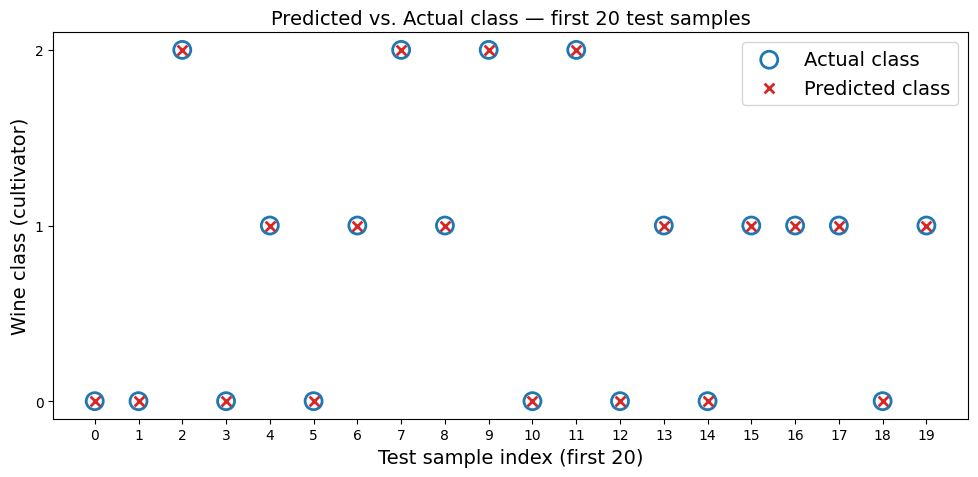

20 / 20 correctly classified in this subset (100.0%)


In [39]:
y_pred = rnd_search_cv.predict(X_test)

n = 20
indices = np.arange(n)
actual = y_test.values[:n]
predicted = y_pred[:n]

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(indices, actual, s=150, facecolors='none', edgecolors='tab:blue',
           linewidths=2, label='Actual class')
ax.scatter(indices, predicted, s=50, color='tab:red', marker='x',
           linewidths=2, label='Predicted class')

# highlight any mismatches
mismatches = indices[actual != predicted]
for m in mismatches:
    ax.axvline(m, color='gray', linestyle=':', alpha=0.4)

ax.set_xlabel("Test sample index (first 20)")
ax.set_ylabel("Wine class (cultivator)")
ax.set_yticks([0, 1, 2])
ax.set_title("Predicted vs. Actual class — first 20 test samples")
ax.set_xticks(indices)
ax.legend(loc='upper right')
save_fig("wine_predicted_vs_actual")
plt.show()

n_correct = (actual == predicted).sum()
print(f"{n_correct} / {n} correctly classified in this subset "
      f"({n_correct / n:.1%})")

# Reflection

**Two real-world business or technology applications of SVM:**

1. **Fraud and anomaly detection in banking/finance** — SVMs can classify transactions as legitimate vs. fraudulent based on features like transaction amount, location, time, and spending patterns, drawing a boundary between "normal" and "suspicious" behavior even when fraud cases are rare and the boundary is non-linear (using a kernelized SVM).
2. **Medical diagnosis from imaging or lab data** — SVMs are widely used to classify tumors as benign vs. malignant from measurements extracted from medical scans or biopsies (this is essentially the same type of task as the classic Breast Cancer Wisconsin dataset), where a clear, well-generalizing decision boundary between classes is critical.

**Difference between `LinearSVC` and a kernelized SVM (`SVC`):**

`LinearSVC` can only learn a **straight-line/flat hyperplane** decision boundary between classes, and it's optimized specifically for the linear case, which makes it fast and scalable to large datasets. A kernelized `SVC` (e.g., with an RBF or polynomial kernel) can learn **curved, non-linear decision boundaries** by implicitly mapping the data into a higher-dimensional space via the kernel trick, without ever explicitly computing that transformation. This makes kernelized SVMs more flexible and often more accurate on data that isn't linearly separable, at the cost of being slower to train on large datasets and having extra hyperparameters (like `gamma`) that need careful tuning.

**Why visualize predicted vs. actual results at the end?**

Numeric summary metrics like accuracy give a single overall number, but they can hide *how* a model fails — for example, whether errors are scattered randomly or concentrated on particular classes or edge cases. Visualizing predictions next to the true labels lets us quickly spot individual misclassifications, notice patterns in the mistakes (e.g., is the model consistently confusing class 1 with class 2?), and build intuition for whether the errors are "reasonable" (e.g., borderline cases) or something more concerning. It also makes the model's real-world performance more concrete and easier to communicate to others than a bare accuracy percentage.

**How AI was used in this assignment:**

Gemini was used to help write and organize the explanatory text cells throughout this notebook — clarifying concepts like feature scaling, the kernel trick, and hyperparameter tuning in plain language — as well as to help debug the `LinearSVC` convergence issue and to write the code for the predicted-vs-actual visualization cell. The underlying model-training code itself follows the standard scikit-learn workflow (train/test split, pipelines, cross-validation, and randomized search) from the course material; the AI's role was explanation, debugging assistance, and generating the additional visualization.